In [35]:
"""
Project Description:
This project aims to evaluate various image denoising techniques on noisy images. The denoising methods applied in this project include:
- Median Filter
- Non-Local Means (NLM) Filter
- Bilateral Filter
- Wavelet-based Denoising
- Hybrid filters (combinations of the above methods)

The evaluation is done using synthetic noise added to the original images, including Gaussian noise and Salt & Pepper noise. The results are compared visually and quantitatively using Peak Signal-to-Noise Ratio (PSNR) and Structural Similarity Index (SSIM).

The goal is to find the most effective denoising method based on PSNR and SSIM values, as well as to provide clear visual comparisons of the denoised images.

Requirements:
- OpenCV
- scikit-image
- NumPy
- Matplotlib
- Pandas
"""

'\nProject Description:\nThis project aims to evaluate various image denoising techniques on noisy images. The denoising methods applied in this project include:\n- Median Filter\n- Non-Local Means (NLM) Filter\n- Bilateral Filter\n- Wavelet-based Denoising\n- Hybrid filters (combinations of the above methods)\n\nThe evaluation is done using synthetic noise added to the original images, including Gaussian noise and Salt & Pepper noise. The results are compared visually and quantitatively using Peak Signal-to-Noise Ratio (PSNR) and Structural Similarity Index (SSIM).\n\nThe goal is to find the most effective denoising method based on PSNR and SSIM values, as well as to provide clear visual comparisons of the denoised images.\n\nRequirements:\n- OpenCV\n- scikit-image\n- NumPy\n- Matplotlib\n- Pandas\n'

In [36]:
import numpy as np  # For numerical operations on image arrays
import cv2  # OpenCV for image I/O and filtering operations
import matplotlib.pyplot as plt  # For displaying images and filter results

from skimage import util, img_as_float, img_as_ubyte, color  # Image utilities and color space conversion
from skimage.restoration import denoise_wavelet  # Denoising techniques
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim  # Quality assessment metrics

import pandas as pd  # For storing evaluation results in tabular format

# Function to load an image and convert it to RGB format
def load_image(image_path):
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise FileNotFoundError(f"Image file not found: {image_path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

In [37]:
# Function to add synthetic Gaussian and Salt & Pepper noise
def add_synthetic_noise(image):
    image_float = img_as_float(image)  # Convert to float for precision in noise addition
    noisy = util.random_noise(image_float, mode='gaussian', var=0.01)  # Add Gaussian noise
    noisy = util.random_noise(noisy, mode='s&p', amount=0.02)  # Add Salt & Pepper noise
    return img_as_ubyte(noisy)  # Convert back to uint8

# Apply multiple denoising techniques on the noisy image
def apply_denoising_methods(noisy_image):
    methods = {}

    # Apply different denoising filters
    methods["Median Filter"] = cv2.medianBlur(noisy_image, 3)
    methods["Non-Local Means"] = cv2.fastNlMeansDenoisingColored(noisy_image, None, 10, 10, 7, 21)
    methods["Bilateral Filter"] = cv2.bilateralFilter(noisy_image, 9, 75, 75)

    # Wavelet-based denoising (works on RGB)
    wavelet_filtered_float = denoise_wavelet(noisy_image, wavelet='db1', mode='soft',
                                             channel_axis=2, rescale_sigma=True)
    methods["Wavelet Filter"] = img_as_ubyte(wavelet_filtered_float)

    # Hybrid filters (chained)
    median_then_nlm = cv2.fastNlMeansDenoisingColored(methods["Median Filter"], None, 10, 10, 7, 21)
    methods["Median + NLM"] = median_then_nlm

    bilateral_then_wavelet_float = denoise_wavelet(methods["Bilateral Filter"], wavelet='db1', mode='soft',
                                                   channel_axis=2, rescale_sigma=True)
    methods["Bilateral + Wavelet"] = img_as_ubyte(bilateral_then_wavelet_float)
    return methods


--- Processing: Images/H-1 (Potential future star-forming regions).jpg ---


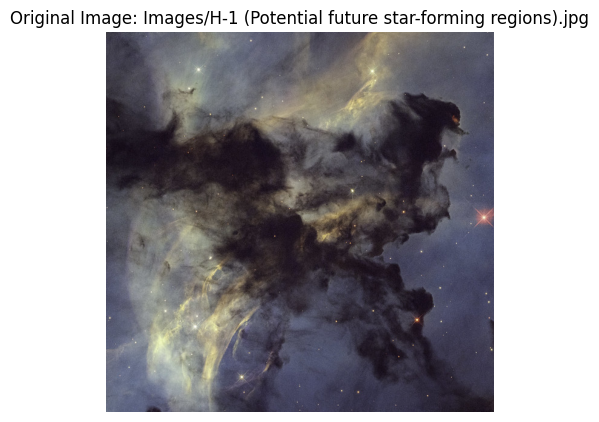

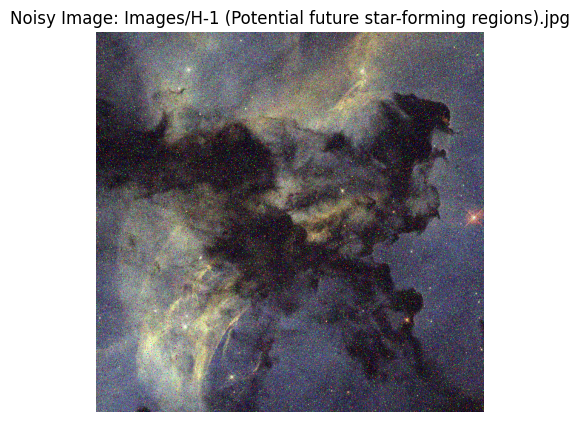

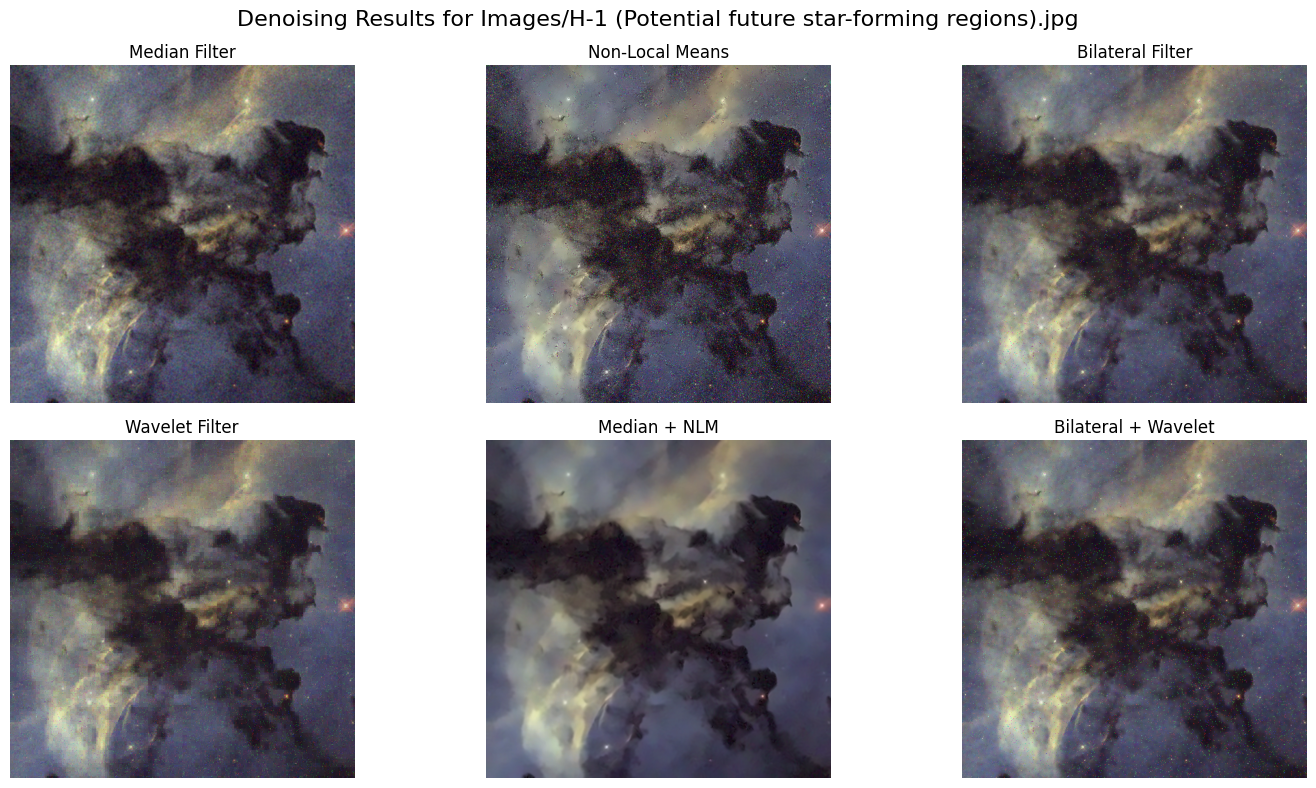

                Method       PSNR      SSIM
0         Median + NLM  31.287132  0.760682
1        Median Filter  28.642016  0.581138
2       Wavelet Filter  26.613938  0.518181
3  Bilateral + Wavelet  26.163973  0.555883
4     Bilateral Filter  25.606830  0.518489
5      Non-Local Means  21.930384  0.344173

--- Processing: Images/H-2 (Active star formation).jpg ---


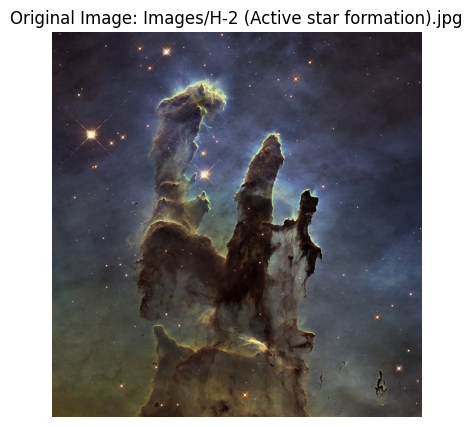

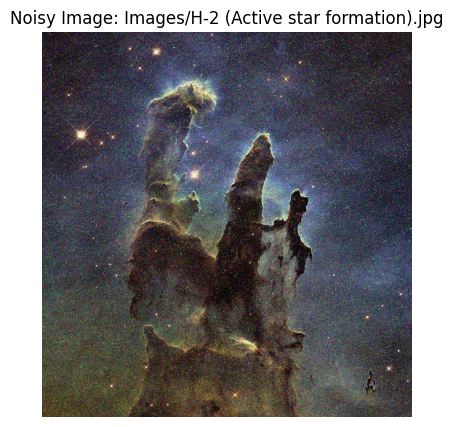

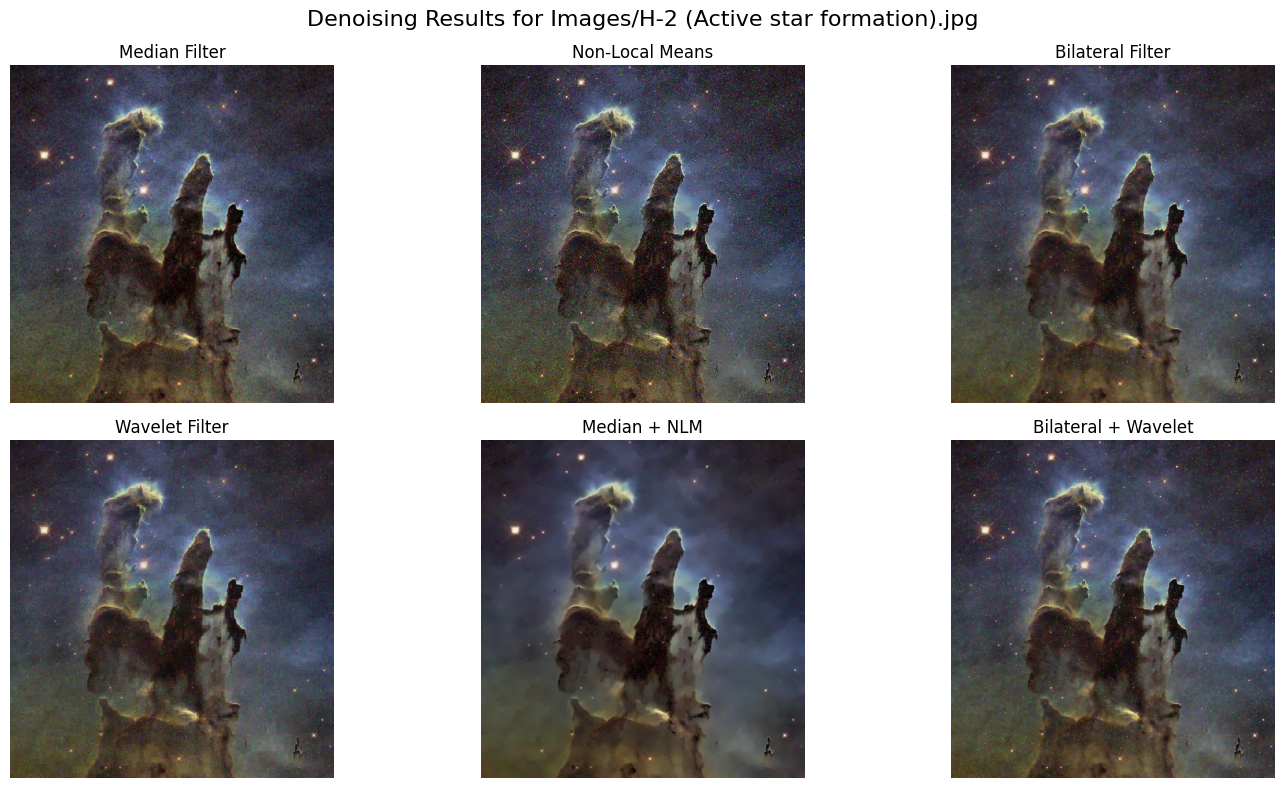

                Method       PSNR      SSIM
0         Median + NLM  31.309296  0.848725
1        Median Filter  28.770811  0.588487
2       Wavelet Filter  26.927862  0.546161
3  Bilateral + Wavelet  26.073844  0.554231
4     Bilateral Filter  25.583982  0.512284
5      Non-Local Means  21.235952  0.256381


In [38]:
# Main processing loop for each image
image_paths = ["Images/H-1 (Potential future star-forming regions).jpg", "Images/H-2 (Active star formation).jpg"]

# Create 'results' directory if it doesn't exist
os.makedirs("results", exist_ok=True)

for path in image_paths:
    print(f"\n--- Processing: {path} ---")
    
    # Load and display the original image
    orig = load_image(path)
    plt.figure(figsize=(5, 5))
    plt.imshow(orig)
    plt.title(f"Original Image: {path}")
    plt.axis("off")
    orig_image_path = f"results/{path.split('/')[-1].split('.')[0]}_original.png"
    plt.savefig(orig_image_path)  # Save original image
    plt.show()
    
    # Add synthetic noise and display
    noisy = add_synthetic_noise(orig)
    plt.figure(figsize=(5, 5))
    plt.imshow(noisy)
    plt.title(f"Noisy Image: {path}")
    plt.axis("off")
    noisy_image_path = f"results/{path.split('/')[-1].split('.')[0]}_noisy.png"
    plt.savefig(noisy_image_path)  # Save noisy image
    plt.show()
    
    # Apply various denoising filters
    methods = apply_denoising_methods(noisy)

    # Display all denoising results side by side (2 rows, 3 columns)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for ax, (title, image) in zip(axes, methods.items()):
        ax.imshow(image)
        ax.set_title(title)
        ax.axis("off")
    plt.suptitle(f"Denoising Results for {path}", fontsize=16)
    denoised_image_path = f"results/{path.split('/')[-1].split('.')[0]}_denoised_grid.png"
    plt.tight_layout()
    plt.savefig(denoised_image_path)  # Save denoised image grid
    plt.show()

    # Quantitative Evaluation using PSNR and SSIM
    orig_gray = color.rgb2gray(orig)
    results = []
    for title, image in methods.items():
        image_gray = color.rgb2gray(image) if image.ndim == 3 else image
        psnr_val = psnr(orig_gray, image_gray, data_range=orig_gray.max() - orig_gray.min())
        ssim_val = ssim(orig_gray, image_gray, data_range=orig_gray.max() - orig_gray.min())
        results.append((title, psnr_val, ssim_val))

    # Create a table of results sorted by PSNR
    df = pd.DataFrame(results, columns=["Method", "PSNR", "SSIM"])
    df_sorted = df.sort_values(by="PSNR", ascending=False).reset_index(drop=True)
    df_sorted.to_csv(f"results/{path.split('/')[-1].split('.')[0]}_evaluation.csv", index=False)  # Save results as CSV
    print(df_sorted)